#### Import Libraries

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, explained_variance_score

#### Import Datasets

In [12]:
%store -r Set1_X_Train_scaled
%store -r Set1_X_Test_scaled
%store -r Set1_y_Train
%store -r Set1_y_Test

#### Random Forest Regression

In [13]:
random_forest_reg = RandomForestRegressor()

Set1_y_Train_array = Set1_y_Train.values.ravel()
Set1_y_Test_array = Set1_y_Test.values.ravel()

random_forest_reg.fit(Set1_X_Train_scaled, Set1_y_Train_array)

rf_reg_pred_train = random_forest_reg.predict(Set1_X_Train_scaled)
rf_reg_pred_test = random_forest_reg.predict(Set1_X_Test_scaled)

#### Random Forest Regression

In [14]:
# Mean Squared Error
mse_train_rf = mean_squared_error(Set1_y_Train_array, rf_reg_pred_train)
mse_test_rf = mean_squared_error(Set1_y_Test_array, rf_reg_pred_test)

# Root Mean Squared Error
rmse_train_rf = np.sqrt(mse_train_rf)
rmse_test_rf = np.sqrt(mse_test_rf)

# Mean Absolute Error
mae_train_rf = mean_absolute_error(Set1_y_Train_array, rf_reg_pred_train)
mae_test_rf = mean_absolute_error(Set1_y_Test_array, rf_reg_pred_test)

# R2 Score
r2_train_rf = r2_score(Set1_y_Train_array, rf_reg_pred_train)
r2_test_rf = r2_score(Set1_y_Test_array, rf_reg_pred_test)

# Coefficient of Determination
cod_train_rf = explained_variance_score(Set1_y_Train_array, rf_reg_pred_train)
cod_test_rf = explained_variance_score(Set1_y_Test_array, rf_reg_pred_test)

# Training Set
print("--Training Set Evaluation--")
print("Mean Squared Error:", mse_train_rf)
print("Root Mean Squared Error:", rmse_train_rf)
print("Mean Absolute Error:", mae_train_rf)
print("R-squared Score:", r2_train_rf)
print("Coefficient of Determination:", cod_train_rf)

# Testing Set
print("--Testing Set Evaluation--")
print("Mean Squared Error:", mse_test_rf)
print("Root Mean Squared Error:", rmse_test_rf)
print("Mean Absolute Error:", mae_test_rf)
print("R-squared Score:", r2_test_rf)
print("Coefficient of Determination:", cod_test_rf)

--Training Set Evaluation--
Mean Squared Error: 244.01329518685472
Root Mean Squared Error: 15.620924914577072
Mean Absolute Error: 10.974216470360137
R-squared Score: 0.9485677199251362
Coefficient of Determination: 0.9485976657774995
--Testing Set Evaluation--
Mean Squared Error: 1323.746653
Root Mean Squared Error: 36.38332932814148
Mean Absolute Error: 28.483299999999996
R-squared Score: 0.23344145209342948
Coefficient of Determination: 0.2448156390094538


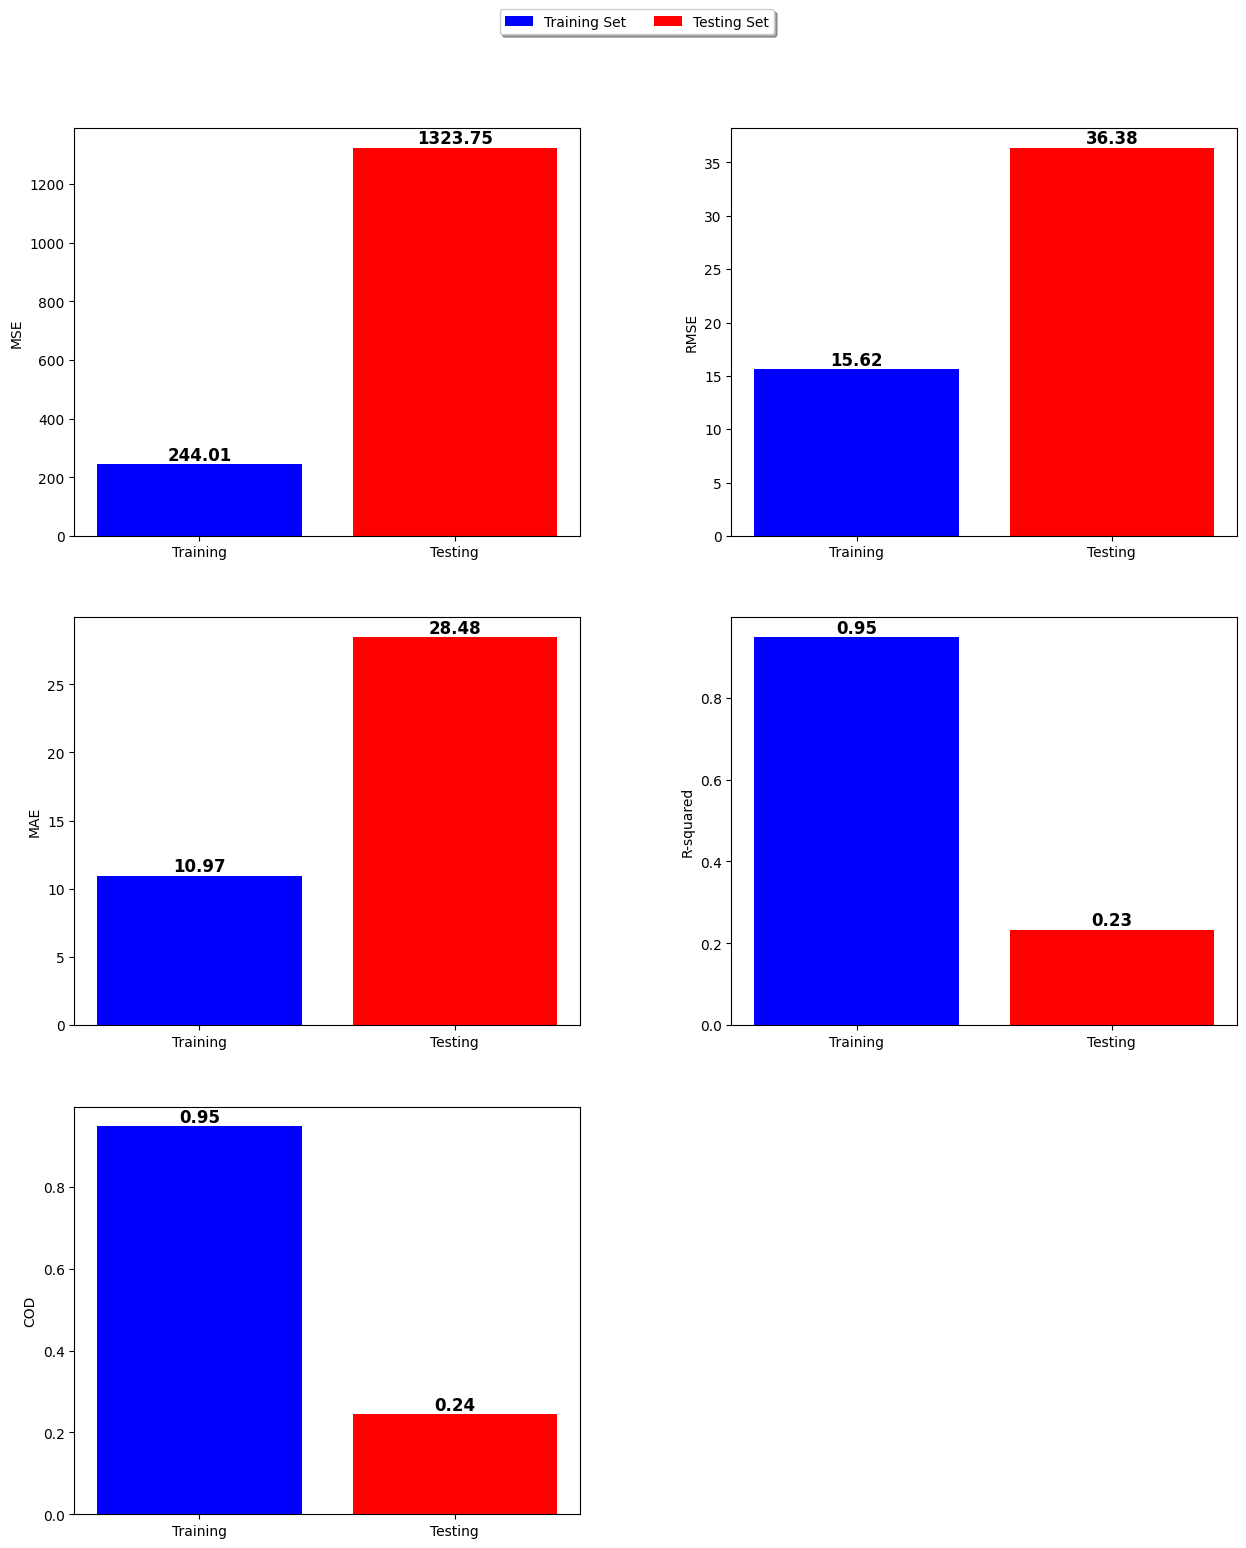

In [15]:
metrics = ['MSE', 'RMSE', 'MAE', 'R-squared', 'COD']
train_metrics = [mse_train_rf, rmse_train_rf, mae_train_rf, r2_train_rf, cod_train_rf]
test_metrics = [mse_test_rf, rmse_test_rf, mae_test_rf, r2_test_rf, cod_test_rf]

num_metrics = len(metrics)
num_cols = 2
num_rows = (num_metrics + num_cols - 1) // num_cols

fig, axes = plt.subplots(num_rows, num_cols, figsize=(15, 6 * num_rows))

for i, (metric, train_metric, test_metric) in enumerate(zip(metrics, train_metrics, test_metrics)):
    ax = axes[i // num_cols, i % num_cols]
    ax.bar('Training', train_metric, color='b', label='Training Set')
    ax.bar('Testing', test_metric, color='r', label='Testing Set')
    ax.set_ylabel(metric)

    for bar in ax.patches:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2, height, round(height, 2), 
                ha='center', va='bottom', fontsize=12, fontweight='bold')

# Position the legend in the middle
handles, labels = ax.get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 0.95), fancybox=True, shadow=True, ncol=2)

for i in range(num_metrics, num_rows * num_cols):
    fig.delaxes(axes.flatten()[i])

plt.subplots_adjust(wspace=0.3)
plt.show()